<a href="https://colab.research.google.com/github/arsingla786/MLFromScratch/blob/main/10Function_Tranformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Convert skewed data into normal data**

In [26]:
import pandas as pd
import seaborn as sns

In [27]:
df = sns.load_dataset('titanic')[['survived','age','fare']]

In [28]:
df.head()

,survived,age,fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [29]:
df.isnull().sum()

,0
survived,0
age,177
fare,0


In [30]:
df['age'].fillna(df['age'].median(),inplace=True)

/tmp/ipykernel_2018/2790788646.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(),inplace=True)


In [31]:
print(df['age'].isnull().sum())

0


In [32]:
X= df.iloc[:,1:3]
y= df.iloc[:,0]

In [33]:
X

,age,fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500
...,...,...
886,27.0,13.0000
887,19.0,30.0000
888,28.0,23.4500
889,26.0,30.0000


In [34]:
y

,survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [35]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(X,y,test_size=0.2,random_state=42)

# **Checking if Age and fare is normally  distributed ?**

/tmp/ipykernel_2018/1201645901.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(xtrain['age'])


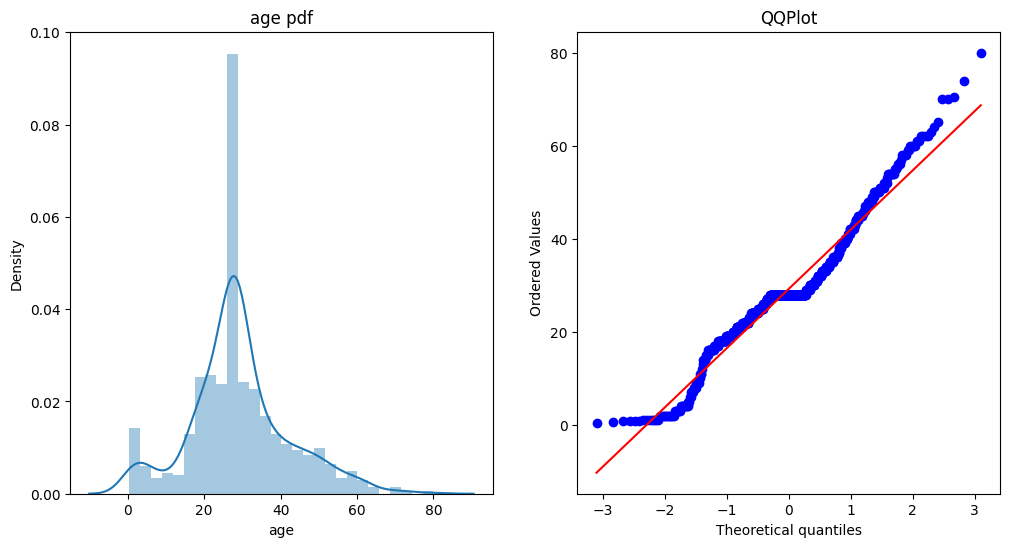

In [36]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

plt.figure(figsize=(12,6))

plt.subplot(121)
sns.distplot(xtrain['age'])
plt.title('age pdf')
plt.subplot(122)
stats.probplot(xtrain['age'],plot=plt)
plt.title('QQPlot')
plt.show()

/tmp/ipykernel_2018/1745906976.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(xtrain['fare'])


Text(0.5, 1.0, 'QQPlot')

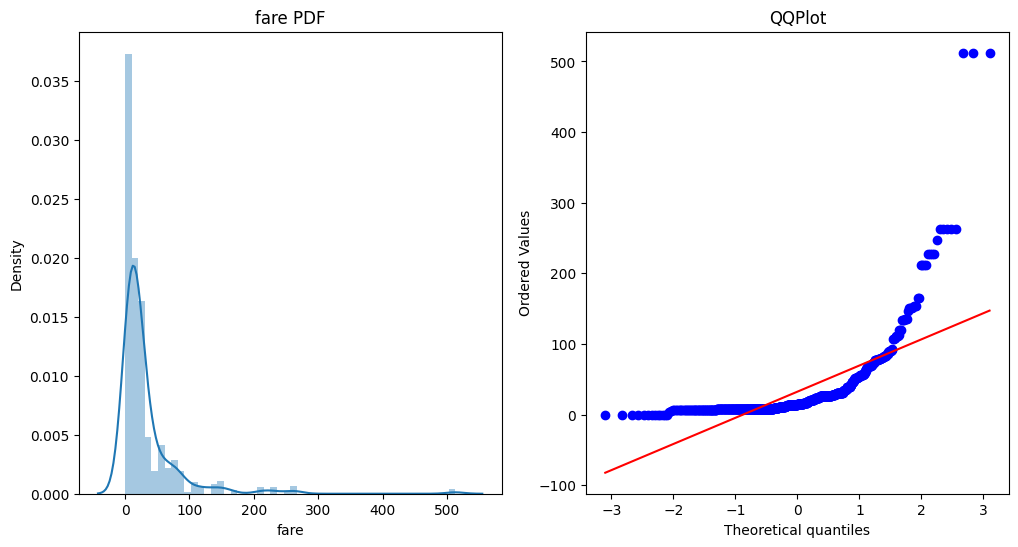

In [37]:
plt.figure(figsize=(12,6))

plt.subplot(121)
sns.distplot(xtrain['fare'])
plt.title('fare PDF')

plt.subplot(122)
stats.probplot(xtrain['fare'],plot=plt)
plt.title('QQPlot')

# **Fare is right Skewed**

# **Model without Log-Transform**

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import  DecisionTreeClassifier
from sklearn.metrics import accuracy_score

m1 = LogisticRegression()
m2 = DecisionTreeClassifier()

m1.fit(xtrain,ytrain)
m2.fit(xtrain,ytrain)

ypred1 = m1.predict(xtest)
ypred2 = m2.predict(xtest)

print(accuracy_score(ytest,ypred1)*100)
print(accuracy_score(ytest,ypred2)*100)


64.80446927374301
67.0391061452514


# **Model after log-transformer**

In [39]:
from sklearn.preprocessing import FunctionTransformer
import numpy as np
trf = FunctionTransformer(func=np.log1p)
xtrain_trf = trf.fit_transform(xtrain)
xtest_trf = trf.transform(xtest)

In [40]:
m1 = LogisticRegression()
m2 = DecisionTreeClassifier()

m1.fit(xtrain_trf,ytrain)
m2.fit(xtrain_trf,ytrain)

ypred1 = m1.predict(xtest_trf)
ypred2 = m2.predict(xtest_trf)

print(accuracy_score(ytest,ypred1)*100)
print(accuracy_score(ytest,ypred2)*100)

67.59776536312849
65.92178770949721


In [41]:
 #there is improvement in Models
 #check again With Cross-Val Score
from sklearn.model_selection import cross_val_score
xtransformed = trf.fit_transform(X)

m1 = LogisticRegression()
m2 = DecisionTreeClassifier()

cv1 = cross_val_score(m1,xtransformed,y,cv=5)
cv2 = cross_val_score(m2,xtransformed,y,cv=5)

print('lr :',cv1.mean()*100)
print('dt :',cv2.mean()*100)

lr : 67.91287427029063
dt : 65.65877848220451


# **Not much impoprovement in Decision tree but , in Logistic Reg.**

Text(0.5, 1.0, 'qqplot after log transform')

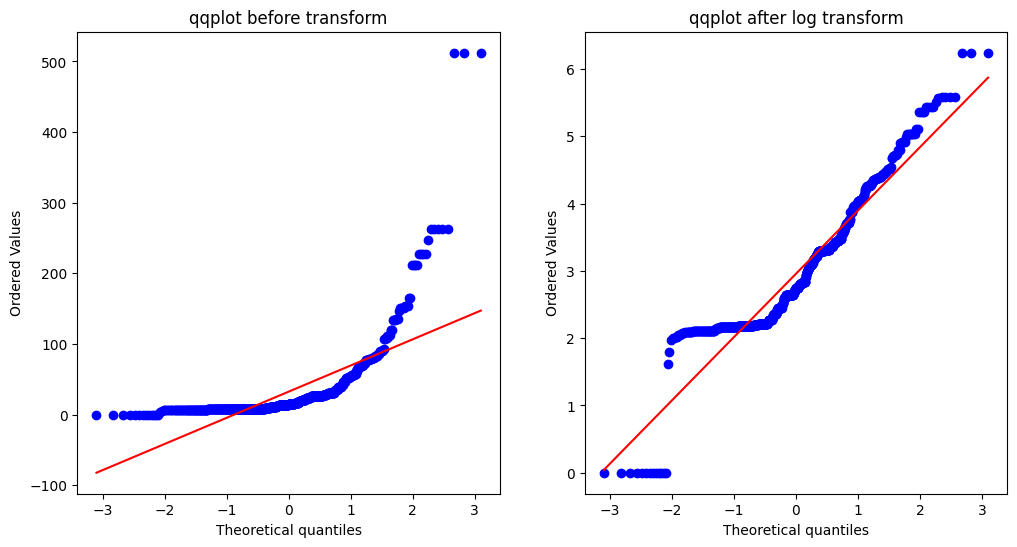

In [42]:
plt.figure(figsize=(12,6))

plt.subplot(121)
stats.probplot(xtrain['fare'],plot = plt)
plt.title('qqplot before transform')

plt.subplot(122)
stats.probplot(xtrain_trf['fare'],plot=plt)
plt.title('qqplot after log transform')

# **Box-Cox Transform**

In [43]:
from sklearn.preprocessing import PowerTransformer
import scipy.stats as stats
import numpy as  np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import  r2_score

In [44]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zain280/concrete-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'concrete-data' dataset.
Path to dataset files: /kaggle/input/concrete-data


In [45]:
df = pd.read_csv('/root/.cache/kagglehub/datasets/zain280/concrete-data/versions/1/concrete_data.csv')

In [46]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [47]:
df.isnull().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Strength,0


# **Train without tranform**

In [48]:
X= df.drop(columns=['Strength'])
y  = df['Strength']

In [49]:
xtrain,xtest,ytrain,ytest = train_test_split(X,y,test_size=0.2,random_state=42)

In [50]:
lr = LinearRegression()
lr.fit(xtrain,ytrain)
ypred= lr.predict(xtest)

In [51]:
r2_score(ytest,ypred)

0.627553179231485

In [52]:
#check with cross val score
np.mean(cross_val_score(lr,X,y,scoring='r2'))

np.float64(0.46099404916628606)

In [57]:
import warnings
warnings.filterwarnings('ignore')

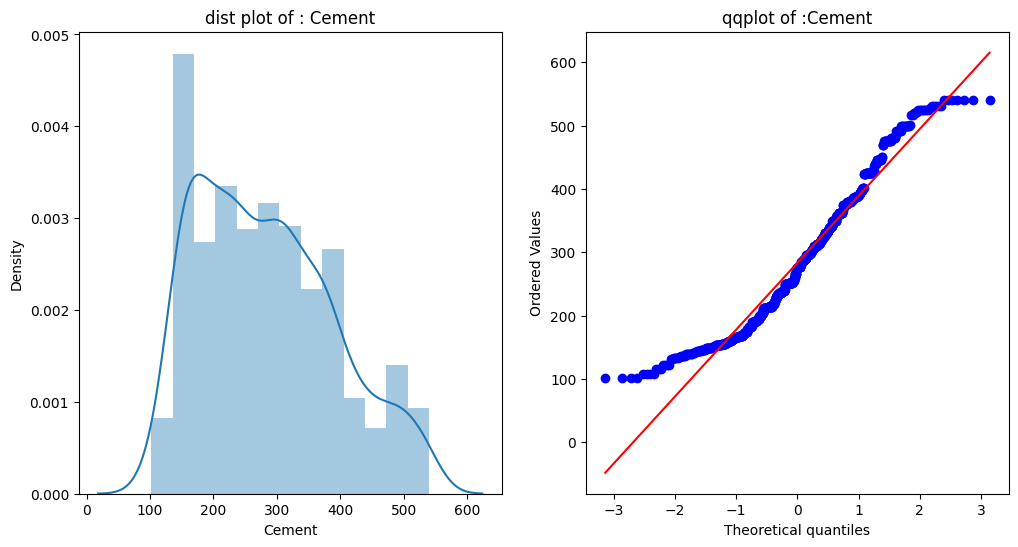

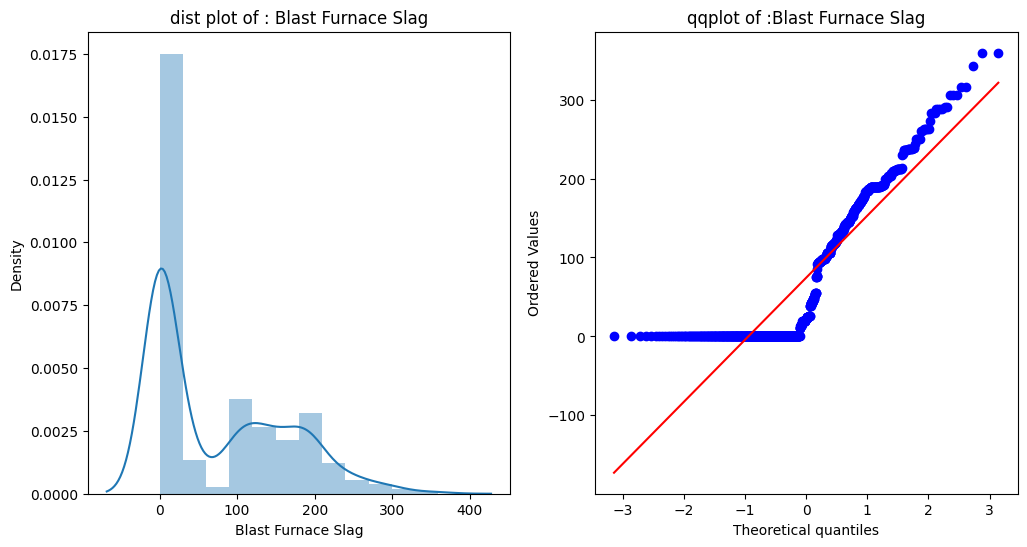

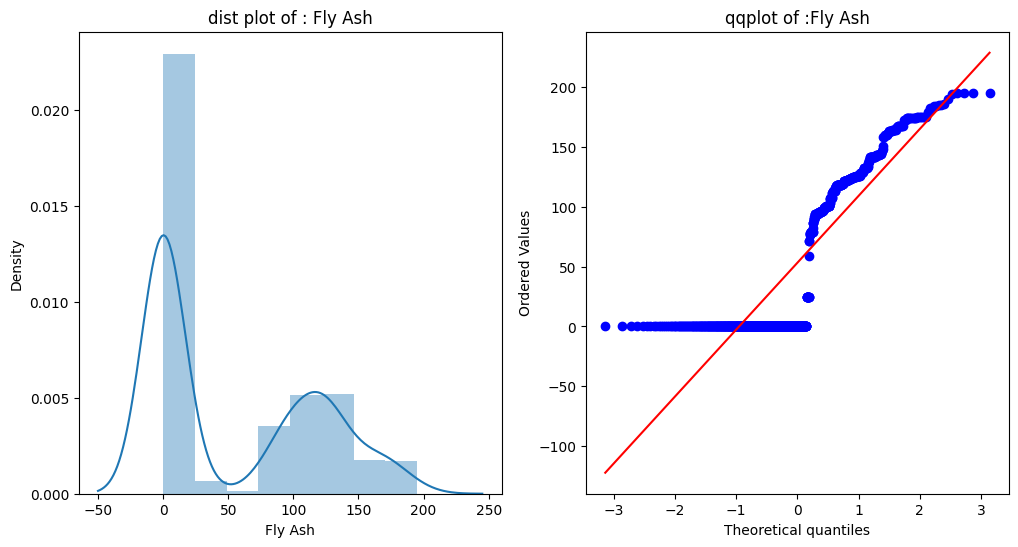

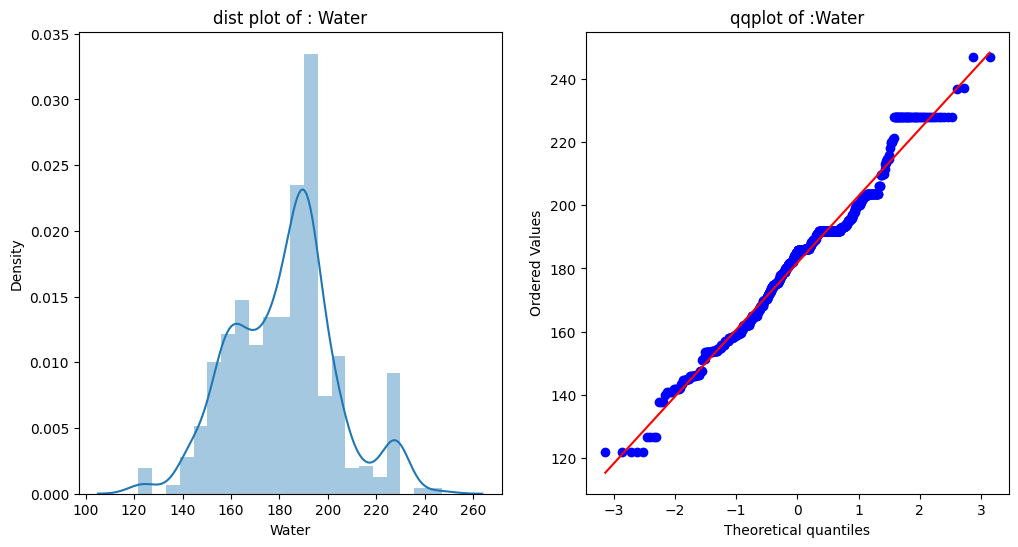

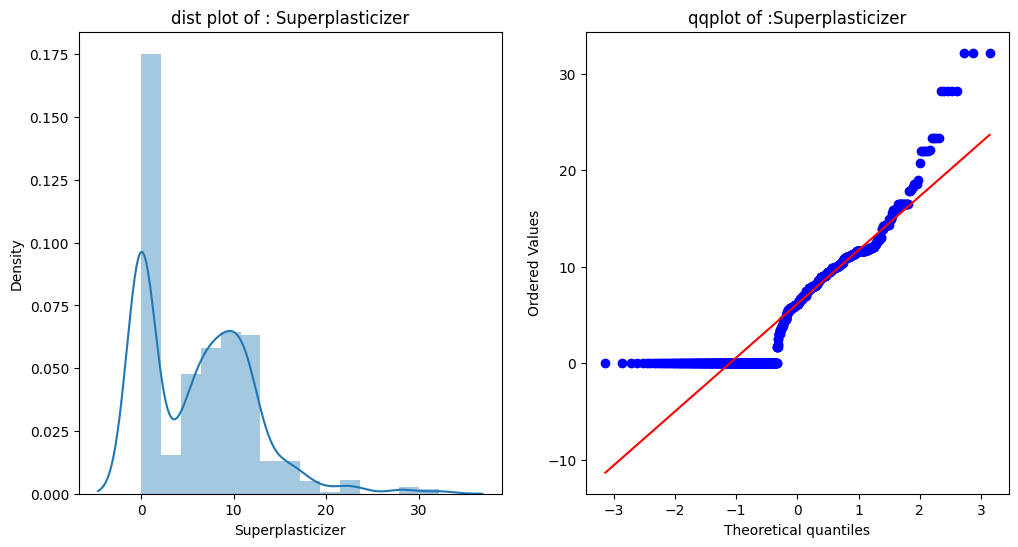

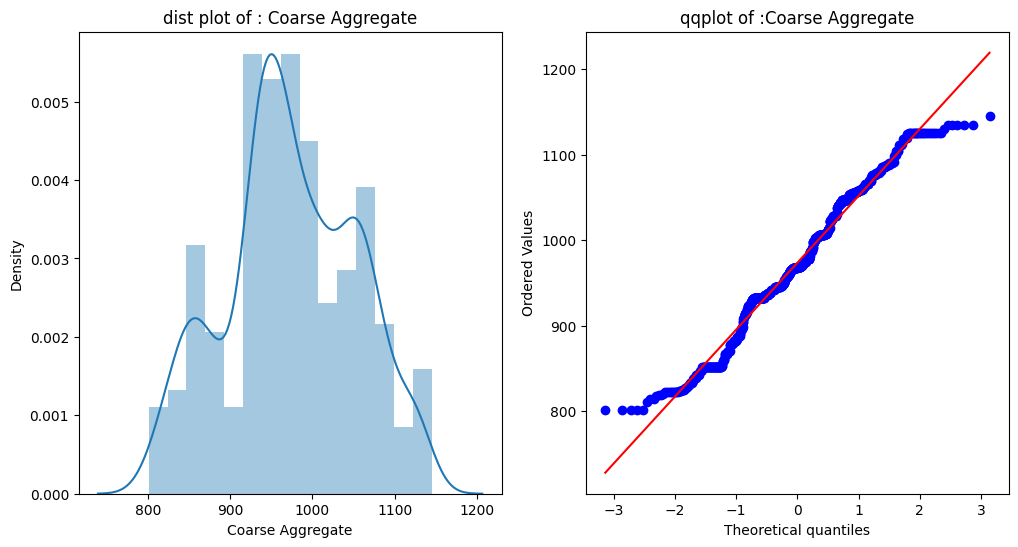

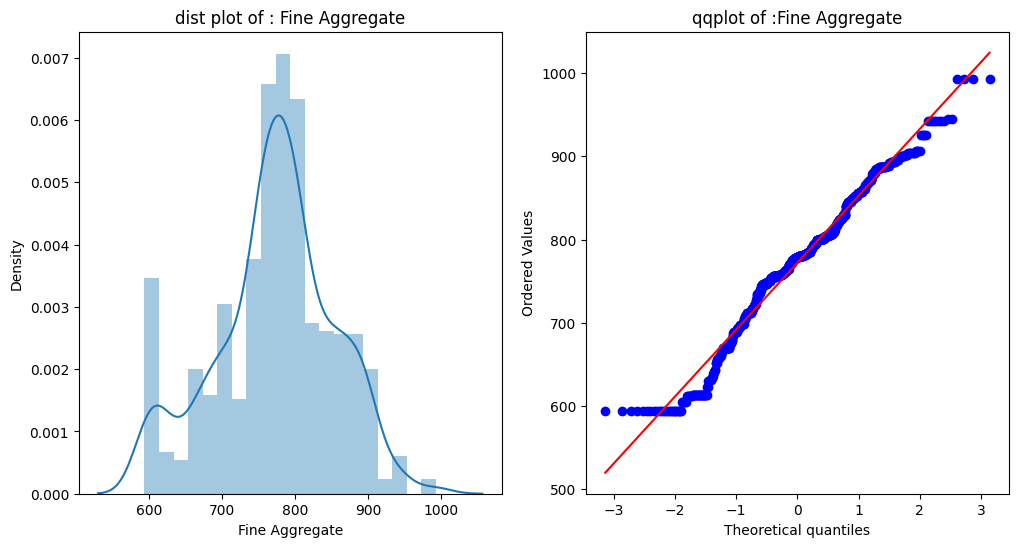

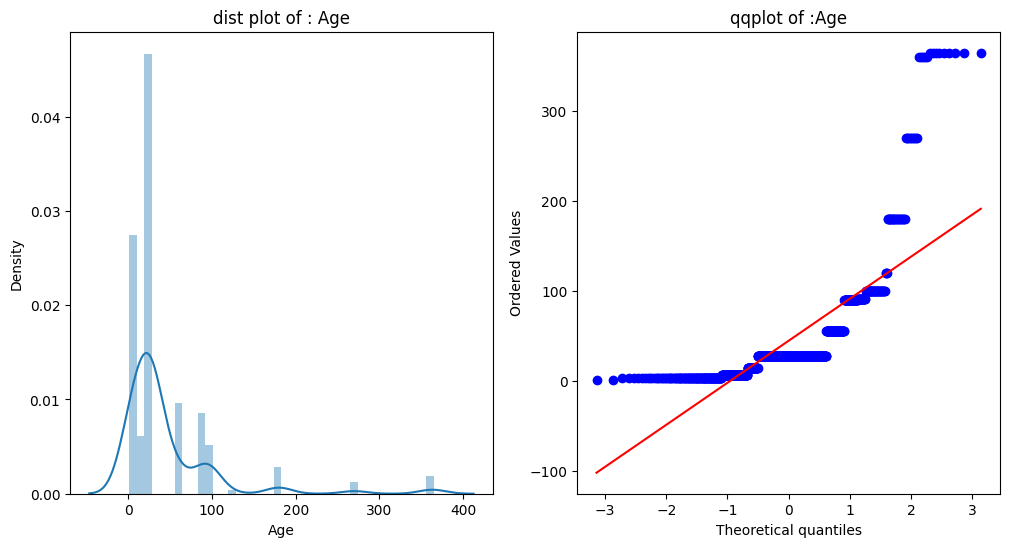

In [59]:
for cols in xtrain.columns:
  plt.figure(figsize=(12,6))
  plt.subplot(121)
  sns.distplot(xtrain[cols])
  plt.title(f"dist plot of : {cols}")

  plt.subplot(122)
  stats.probplot(xtrain[cols],dist="norm",plot=plt)
  plt.title(f'qqplot of :{cols}')

# **APPLY BOX-COX TRANSFORM**

In [60]:
#many columns are not normally distributed
#we have to use transformers
pt = PowerTransformer(method='box-cox')
xtrain_trf = pt.fit_transform(xtrain+0.0000001)
xtest_trf = pt.transform(xtest+0.0000001)

pd.DataFrame({'cols':xtrain.columns,'box-cox lambda':pt.lambdas_})

,cols,box-cox lambda
0,Cement,0.177025
1,Blast Furnace Slag,0.022767
2,Fly Ash,-0.034635
3,Water,0.772682
4,Superplasticizer,0.087141
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066631


In [61]:
#apply lr model again
lr = LinearRegression()
lr.fit(xtrain_trf,ytrain)
ypred = lr.predict(xtest_trf)
r2_score(ytest,ypred)

0.8042534500441562

In [63]:
x_transformed = pt.fit_transform(X+0.0000001)
np.mean(cross_val_score(lr,x_transformed,y,scoring='r2'))

np.float64(0.6658537935432477)

In [64]:
xtrain_trf = pd.DataFrame(xtrain_trf,columns=xtrain.columns)
xtest_trf = pd.DataFrame(xtest_trf,columns=xtest.columns)

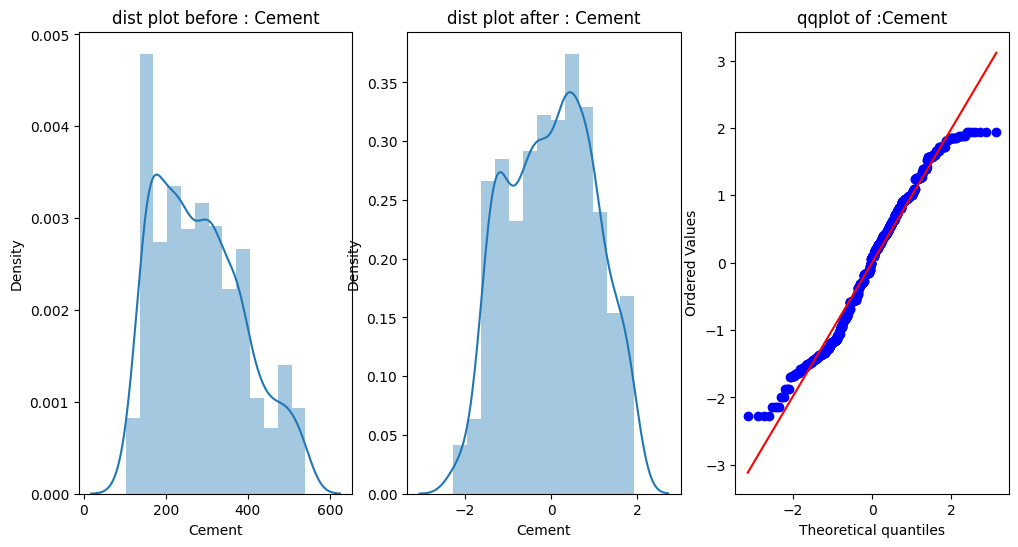

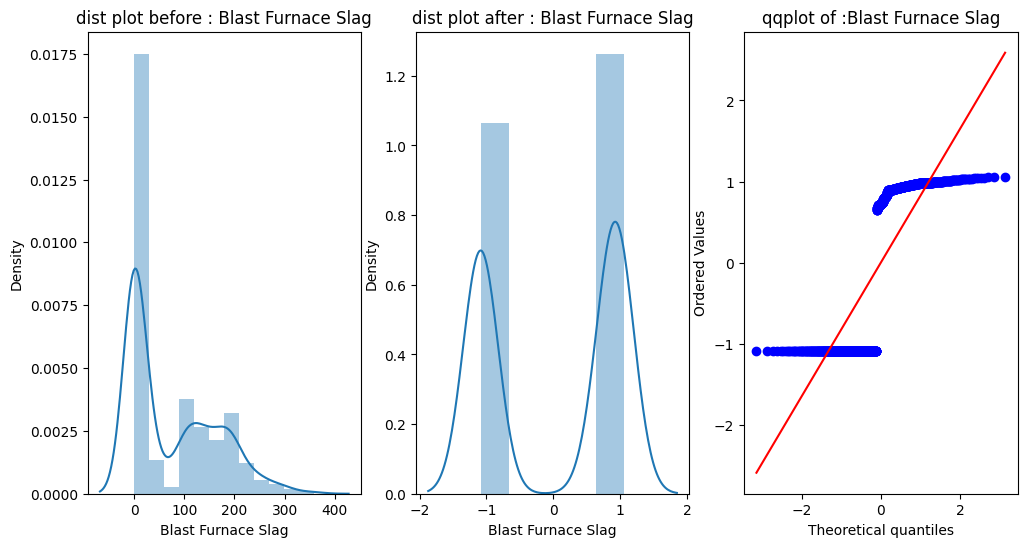

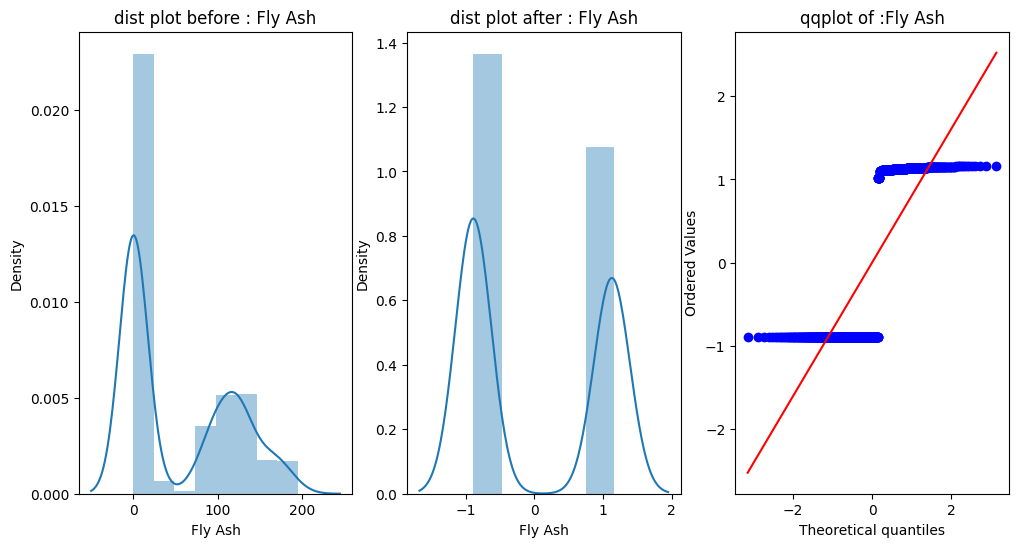

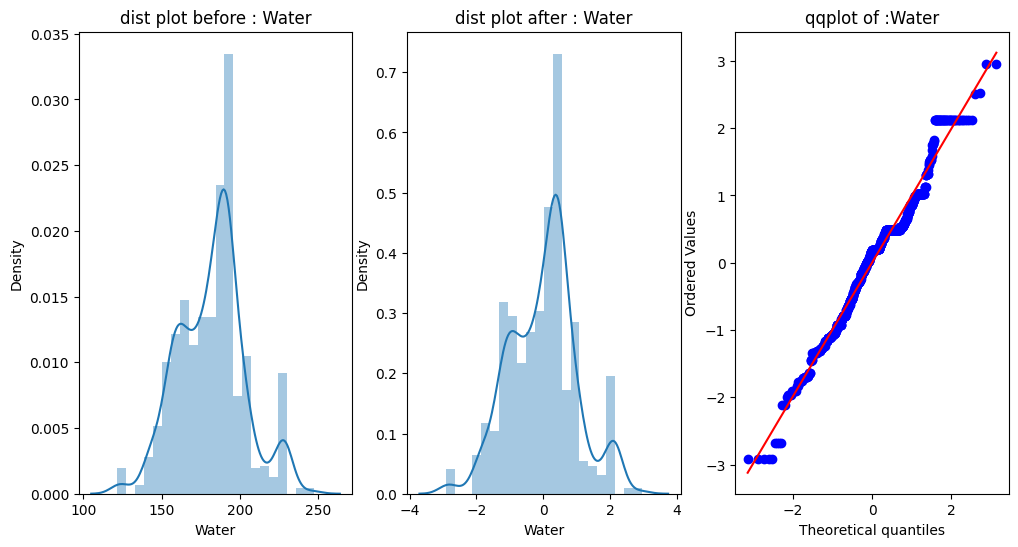

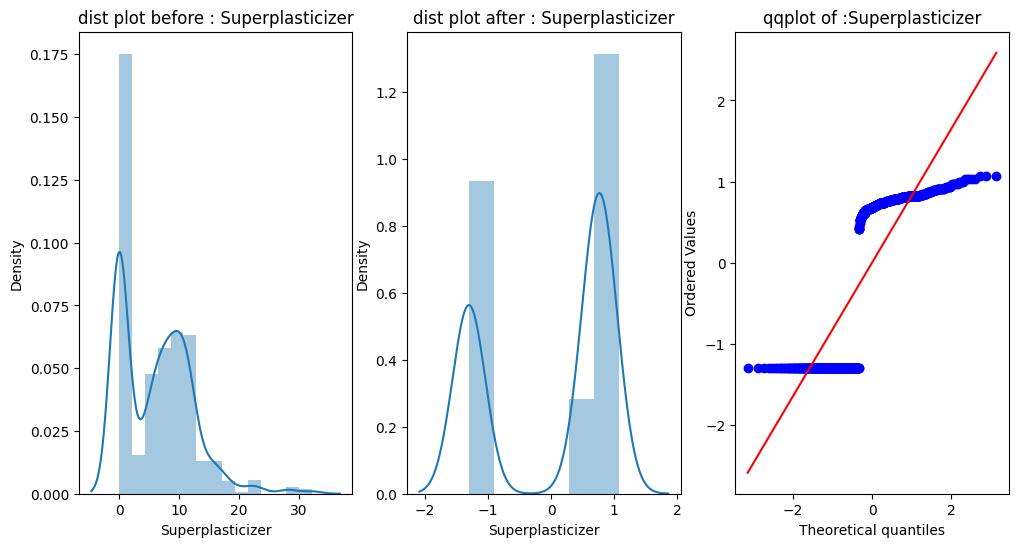

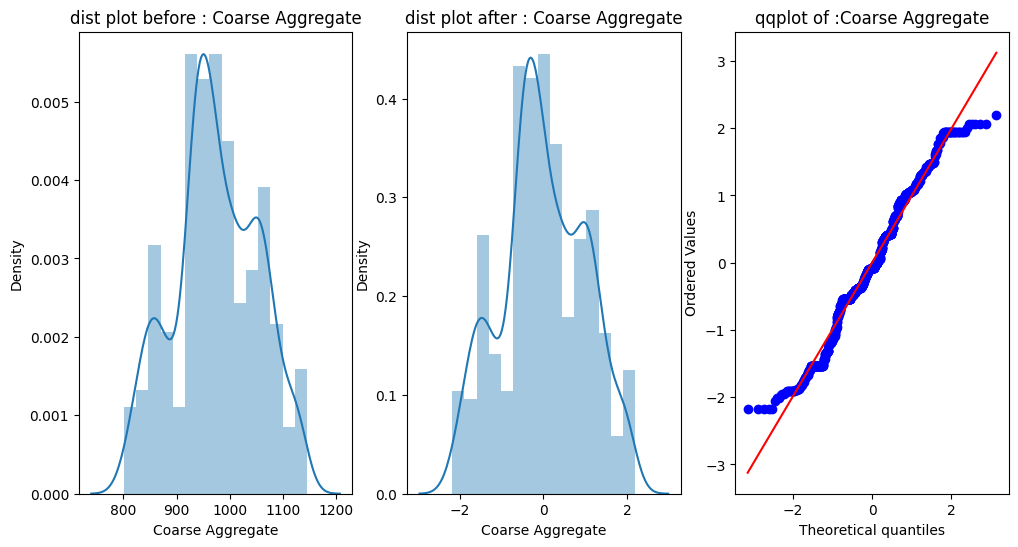

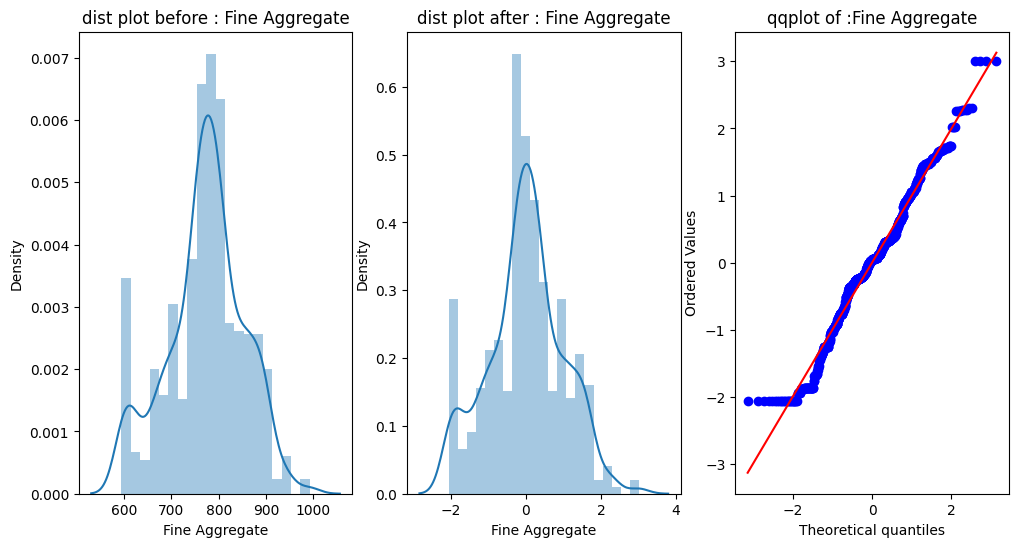

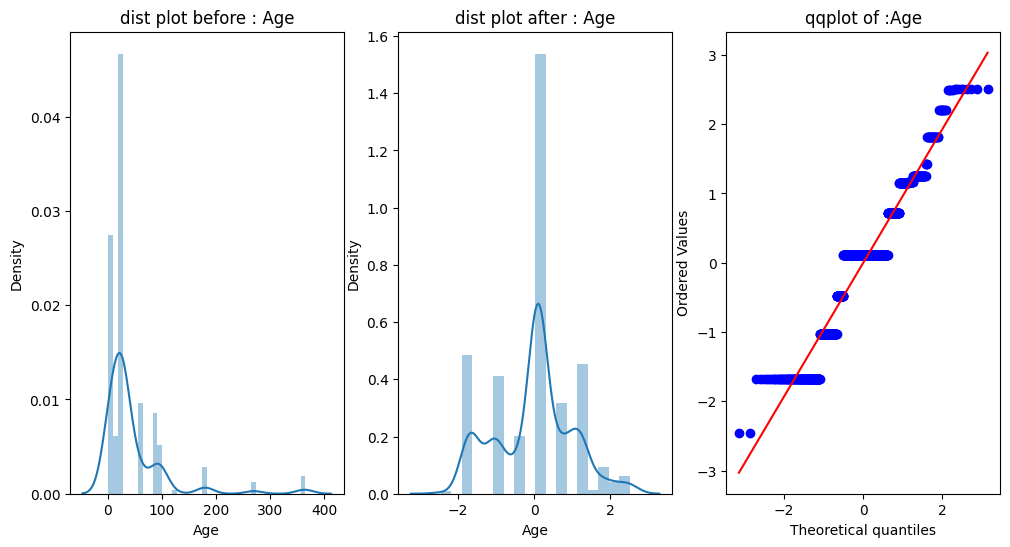

In [67]:
#compare before and after distributions
for cols in xtrain.columns:
  plt.figure(figsize=(12,6))
  plt.subplot(131)
  sns.distplot(xtrain[cols])
  plt.title(f"dist plot before : {cols}")

  plt.subplot(132)
  sns.distplot(xtrain_trf[cols])
  plt.title(f"dist plot after : {cols}")

  plt.subplot(133)
  stats.probplot(xtrain_trf[cols],dist="norm",plot=plt)
  plt.title(f'qqplot of :{cols}')